In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
 89% 705M/788M [00:08<00:02, 40.3MB/s]
100% 788M/788M [00:08<00:00, 95.0MB/s]


In [ ]:
!mv microsoft-catsvsdogs-dataset.zip dog-vs-cat.zip

In [ ]:
!unzip -q dog-vs-cat.zip

In [ ]:
import os

path = "/content/PetImages"
print(os.listdir(path))

['Dog', 'Cat']


In [ ]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12501
Cat images: 12501


In [ ]:
from PIL import Image

dataset_path = 'PetImages'
classes = ['Cat', 'Dog']

for cls in classes:
    path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError) as e:
            print(f'Removing (Corrupted): {img_path}')
            os.remove(img_path)

Removing (Corrupted): PetImages/Cat/666.jpg
Removing (Corrupted): PetImages/Cat/Thumbs.db
Removing (Corrupted): PetImages/Dog/11702.jpg
Removing (Corrupted): PetImages/Dog/Thumbs.db


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
import random
import os

def balance_folder(folder_path, target_count):
    current_images = os.listdir(folder_path)
    if len(current_images) > target_count:
        to_remove = random.sample(current_images, len(current_images) - target_count)
        for img in to_remove:
            os.remove(os.path.join(folder_path, img))

# Define min_count based on previously calculated dog_count and cat_count
min_count = min(dog_count, cat_count)

balance_folder(os.path.join(dataset_path, 'Cat'), min_count)
balance_folder(os.path.join(dataset_path, 'Dog'), min_count)

print("Dataset successfully cleaned and balanced!")

Dataset successfully cleaned and balanced!


In [ ]:
cat_images = os.listdir(os.path.join(dataset_path, 'Cat'))
dog_images = os.listdir(os.path.join(dataset_path, 'Dog'))

min_count = min(len(cat_images), len(dog_images))
print(f"Number of images retained for balancing: {min_count}")

Number of images retained for balancing: 12499


In [ ]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12499
Cat images: 12499


In [ ]:
import os, shutil

original_dataset_dir = 'PetImages'

base_dir = 'data/cats_dogs'

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
os.makedirs(base_dir)

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

for directory in [train_dir, validation_dir, test_dir]:
    os.makedirs(os.path.join(directory, 'cats'))
    os.makedirs(os.path.join(directory, 'dogs'))

def split_and_copy_images(animal_type, source_folder, train_dest, val_dest, test_dest):
    fnames = os.listdir(source_folder)
    fnames = [f for f in fnames if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    fnames.sort()

    total_images = len(fnames)
    train_end = int(total_images * 0.8)
    val_end = int(total_images * 0.9)

    train_fnames = fnames[:train_end]
    val_fnames = fnames[train_end:val_end]
    test_fnames = fnames[val_end:]

    for fname in train_fnames:
        shutil.copyfile(os.path.join(source_folder, fname), os.path.join(train_dest, fname))

    for fname in val_fnames:
        shutil.copyfile(os.path.join(source_folder, fname), os.path.join(val_dest, fname))

    for fname in test_fnames:
        shutil.copyfile(os.path.join(source_folder, fname), os.path.join(test_dest, fname))

    print(f"{animal_type} -> Total: {total_images} | Train: {len(train_fnames)} | Validation: {len(val_fnames)} | Test: {len(test_fnames)}")

print("Copying images... (This might take a minute or two for 25k images)")
try:
    copy_cats = split_and_copy_images('Cats', os.path.join(original_dataset_dir, 'Cat'), os.path.join(train_dir, 'cats'), os.path.join(validation_dir, 'cats'), os.path.join(test_dir, 'cats'))
    copy_dogs = split_and_copy_images('Dogs', os.path.join(original_dataset_dir, 'Dog'), os.path.join(train_dir, 'dogs'), os.path.join(validation_dir, 'dogs'), os.path.join(test_dir, 'dogs'))
except FileNotFoundError as e:
    print(f"Error: A path was not found. Please check if the original folder name is exactly correct. Details: {e}")

print('\nDone!')

Copying images... (This might take a minute or two for 25k images)
Cats -> Total: 12499 | Train: 9999 | Validation: 1250 | Test: 1250
Dogs -> Total: 12499 | Train: 9999 | Validation: 1250 | Test: 1250

Done!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:

train_dir = 'data/cats_dogs/train'
validation_dir = 'data/cats_dogs/validation'
test_dir = 'data/cats_dogs/test'

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess
)

test_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess
)


print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Loading Validation Data...")
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Loading Test Data...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # IMPORTANT: Do tions aligned with true labels
)

Loading Training Data...
Found 19998 images belonging to 2 classes.
Loading Validation Data...
Found 2500 images belonging to 2 classes.
Loading Test Data...
Found 2500 images belonging to 2 classes.


In [ ]:

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    filepath='best_cats_dogs_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

epochs = 20

print("Training Starting...")
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[checkpoint, reduce_lr, early_stopping]
)

Training Starting...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8181 - loss: 1.1196
Epoch 1: val_accuracy improved from -inf to 0.97440, saving model to best_cats_dogs_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 336s 514ms/step - accuracy: 0.8183 - loss: 1.1187 - val_accuracy: 0.9744 - val_loss: 0.0969 - learning_rate: 1.0000e-04
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9472 - loss: 0.1905
Epoch 2: val_accuracy improved from 0.97440 to 0.98160, saving model to best_cats_dogs_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.9472 - loss: 0.1904 - val_accuracy: 0.9816 - val_loss: 0.0640 - learning_rate: 1.0000e-04
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9565 - loss: 0.1320
Epoch 3: val_accuracy did not improve from 0.98160
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 491ms/step - accuracy: 0.9565 - loss: 0.1319 - val_accuracy: 0.9800 - val_loss: 0.0607 - learning_rate: 1.0000e-04
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9640 - loss: 0.1045
Epoch 4: val_accuracy improved from 0.98160 to 0.98560, saving model to best_cats_dogs_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 502ms/step - accuracy: 0.9640 - loss: 0.1045 - val_accuracy: 0.9856 - val_loss: 0.0458 - learning_rate: 1.0000e-04
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9686 - loss: 0.0883
Epoch 5: val_accuracy did not improve from 0.98560
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 501ms/step - accuracy: 0.9686 - loss: 0.0883 - val_accuracy: 0.9856 - val_loss: 0.0440 - learning_rate: 1.0000e-04
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9689 - loss: 0.0812
Epoch 6: val_accuracy improved from 0.98560 to 0.98760, saving model to best_cats_dogs_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 500ms/step - accuracy: 0.9689 - loss: 0.0812 - val_accuracy: 0.9876 - val_loss: 0.0425 - learning_rate: 1.0000e-04
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9703 - loss: 0.0761
Epoch 7: val_accuracy did not improve from 0.98760
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 499ms/step - accuracy: 0.9703 - loss: 0.0761 - val_accuracy: 0.9876 - val_loss: 0.0406 - learning_rate: 1.0000e-04
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9691 - loss: 0.0760
Epoch 8: val_accuracy did not improve from 0.98760
625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 497ms/step - accuracy: 0.9691 - loss: 0.0760 - val_accuracy: 0.9864 - val_loss: 0.0426 - learning_rate: 1.0000e-04
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9727 - loss: 0.0740
Epoch 9: val_accuracy improved from 0.98760 to 0.98880, saving model to best_cats_dogs_model.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 311s 498ms/step - accuracy: 0.9727 - loss: 0.0740 - val_accuracy: 0.9888 - val_loss: 0.0402 - learning_rate: 1.0000e-04
Epoch 10/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9740 - loss: 0.0685
Epoch 10: val_accuracy did not improve from 0.98880
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 500ms/step - accuracy: 0.9740 - loss: 0.0685 - val_accuracy: 0.9876 - val_loss: 0.0449 - learning_rate: 1.0000e-04
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9749 - loss: 0.0647
Epoch 11: val_accuracy did not improve from 0.98880
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 502ms/step - accuracy: 0.9749 - loss: 0.0647 - val_accuracy: 0.9880 - val_loss: 0.0387 - learning_rate: 1.0000e-04
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9765 - loss: 0.0578
Epoch 12: val_accuracy did not improve from 0.98880
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 503ms/step - accuracy: 0.9765 - loss: 0.0578 - val_accuracy: 0.9884 - val_loss: 0.0449 - learnin


Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 502ms/step - accuracy: 0.9803 - loss: 0.0524 - val_accuracy: 0.9892 - val_loss: 0.0411 - learning_rate: 5.0000e-05
Epoch 18/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.9798 - loss: 0.0510
Epoch 18: val_accuracy did not improve from 0.98920
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 502ms/step - accuracy: 0.9798 - loss: 0.0510 - val_accuracy: 0.9888 - val_loss: 0.0388 - learning_rate: 2.5000e-05
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 13.


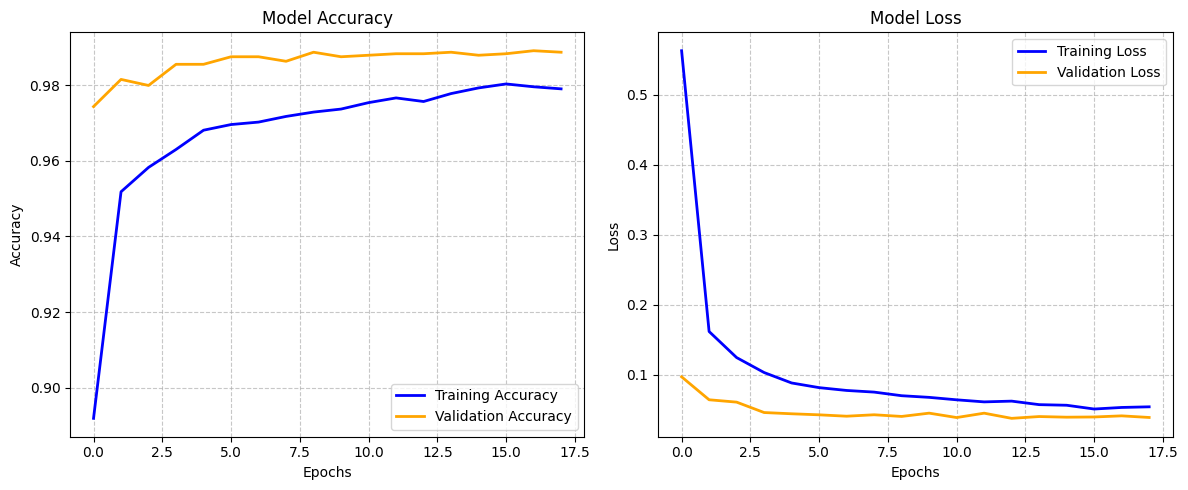

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:

print("Evaluating the model using Test Data")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nLast Test Loss value: {test_loss:.4f}")
print(f"last Test Accuracy value: {test_accuracy * 100:.2f}%")

Evaluating the model using Test Data
44/79 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.9864 - loss: 0.0422

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.9854 - loss: 0.0478

Last Test Loss value: 0.0466
last Test Accuracy value: 98.64%


Getting predictions...
44/79 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step


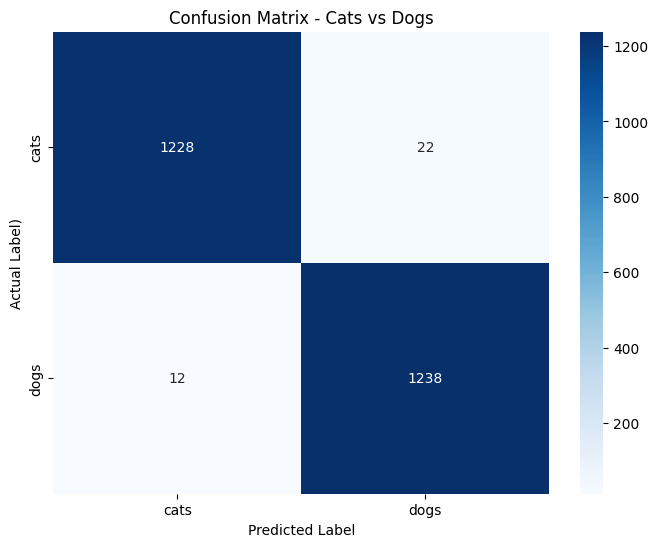

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Getting predictions...")
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Cats vs Dogs')
plt.ylabel('Actual Label)')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

Classification Report:

              precision    recall  f1-score   support

        cats       0.99      0.98      0.99      1250
        dogs       0.98      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


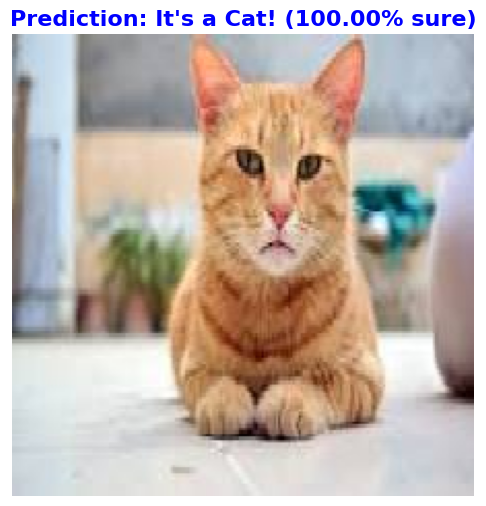

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

image_path = 'my_test_image.jpg'

img = image.load_img(image_path, target_size=(224, 224))

img_array = image.img_to_array(img)

img_batch = np.expand_dims(img_array, axis=0)

processed_image = preprocess_input(img_batch.copy())

predictions = model.predict(processed_image)

predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

class_names = ['Cat', 'Dog']
result = class_names[predicted_class_index]

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')

text_color = 'blue' if result == 'Cat' else 'green'
plt.title(f"Prediction: It's a {result}! ({confidence:.2f}% sure)", fontsize=16, color=text_color, fontweight='bold')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


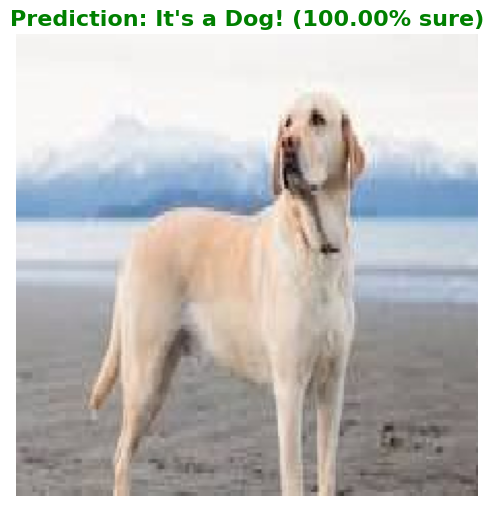

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

image_path = 'my_test_image2.jpg'

img = image.load_img(image_path, target_size=(224, 224))

img_array = image.img_to_array(img)

img_batch = np.expand_dims(img_array, axis=0)

processed_image = preprocess_input(img_batch.copy())

predictions = model.predict(processed_image)

predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

class_names = ['Cat', 'Dog']
result = class_names[predicted_class_index]

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')

text_color = 'blue' if result == 'Cat' else 'green'
plt.title(f"Prediction: It's a {result}! ({confidence:.2f}% sure)", fontsize=16, color=text_color, fontweight='bold')

plt.show()

In [29]:
model_name = 'best_cats_dogs_model.h5'
destination_path = '/content/drive/MyDrive/' + model_name
shutil.copy(model_name, destination_path)
print(f"\n'{model_name}' Save Succesfully")


'best_cats_dogs_model.h5' Save Succesfully
